In [98]:
import warnings
warnings.filterwarnings('ignore')

#random
from IPython.display import display, HTML
from tabulate import tabulate
from itertools import product
import matplotlib.ticker as mtick

#basics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree

#regression estimators
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
#from sklearn.svm import SVR
from sklearn.svm import LinearSVR as SVR
#model metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

%matplotlib inline

#run cross validation for several models (models can be added)
def get_model(X,y,modelType,folds):
    algos = []
    algos.append(('dtc', DecisionTreeClassifier(random_state=89129)))
    algos.append(('rfc',RandomForestClassifier(random_state=89129)))
    algos.append(('gbc',GradientBoostingClassifier(random_state=89129)))
    algos.append(('rfr',RandomForestRegressor(random_state=89129)))
    algos.append(('lr',LinearRegression()))
    algos.append(('svr',SVR(random_state=89129)))
    results={}
    result_means={}
    for name, model in algos:
        if modelType=='c' and name in ('dtc','rfc','gbc'):
            print('running classification cross val for %s with %s folds' %(name,folds))
            result=cross_val_score(model,X,y,cv=folds,scoring='accuracy', )
            results[name]=result
    for name, model in algos:
        if modelType=='r' and name in ('rfr','lr','svr'):
            print('running regression cross val for %s with %s folds' %(name,folds))
            result=cross_val_score(model,X,y,cv=folds,scoring='r2', )
            results[name]=result
    for key in results:
        result_means[key]=results[key].mean()
    model=min(result_means, key=result_means.get)    
    return(model)

#after a model is returned, test the model and store accuracy/feature importance information
def get_acc (X,y,ind_vars,dep_var,model,ts,folds,depth):

    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=ts,random_state=89129)
    if model=='dtc':
        algo= DecisionTreeClassifier(max_depth=depth)
    elif model=='rfc':
        algo=RandomForestClassifier(max_depth=depth)
    elif model=='gbc':
        algo=GradientBoostingClassifier(max_depth=depth)
    elif model=='rfr':
        algo=RandomForestRegressor(n_jobs=depth)
    elif model=='lr':
        algo=LinearRegression(n_jobs=depth)
    elif model=='svr':
        algo=SVR()

    ML = algo.fit(X_train,y_train)
    preds = ML.predict(X_test)
    importance={}
    if model in ('dtc','rfc','gbc'):
        df_add=pd.DataFrame({'model':model,'ind_vars':[ind_vars],'dep_var':dep_var,'folds':[folds],'depth':[depth],'accuracy':[classification_report(y_test,preds,output_dict=True)['accuracy']]})
        importanceZ = zip(X.columns, ML.feature_importances_)
    elif model in ('rfr','lr','svr'):
        #rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2=r2_score(y_test, preds)
        df_add=pd.DataFrame({'model':model,'ind_vars':[ind_vars],'dep_var':dep_var,'folds':[folds],'depth':[depth],'accuracy':r2})
        importanceZ = zip(X.columns, ML.coef_)      
    for feat,score in importanceZ:
            importance[feat]=[score]    
    return({'df':df_add,'imp':importance,'X_test':X_test,'y_test':y_test,'preds':preds})

# Predict limit balance based on non-defaulted transactions

In [100]:
#####initial variable set up#####

#pick the independent/dependent variables and set up appropriate dataframes
ind_vars=['SEX','EDUCATION','MARRIAGE','AGE','PAY_0']
dep_var='LIMIT_BAL'

#decide if were running regression or classification (r or c)
model_type='r'

#variable to hold the proportion of data to test on
test_prop=0.3

#arrays to hold the possible folds to use during cross validation as well as the possible depths/n_lines to use during modeling
folds = [5]
depths=[3]

#check to see if any variables are constant.  Remove if they are.
for var in ind_vars:
        if data[var].max()==data[var].min():
            ind_vars.remove(var)

            
#####loop through the choices#####
#Sometimes it seems helpful to look for patterns in slices of the original dataset
#This dataframe will hold the accuracy for of the best model for each slice considered
df_acc_graph=pd.DataFrame(columns=['DEFAULT','max accuracy'])

#This loop allows us to run the same analysis on several slices of the data
#in this particlar problem were interested in predicting based on non-defaulters' behavior, so we'll use default=0 as our only slice
for r in range(0,1):
    data = pd.read_csv('credit_cleaned_transformed.csv')
    data=data[data['DEFAULT']==r]
    X=data[ind_vars]
    #print(X.head())
    y=data[dep_var]
    #print(y.head())
    #prettify results
    display(HTML('<h3>Default = '+str(r)+'</h3>'))
    display(HTML('<hr>'))

#This dataframe holds results from each individual model ran (not necesarily the best model)
    classify=pd.DataFrame(columns=['model','ind_vars','dep_var','folds','depth','accuracy'])
    
#this dataframe holds feature importance type data
    df_imp=pd.DataFrame()
    
#This loop allows the number of cross validation folds (f) as well as the depth/n_jobs (d) of the model to be adjusted 
    for f,d in product(folds,depths):
        try:
            model=get_model(X,y,model_type,f)
            print('get_model finished...')
            print('Result:'+model)
            print('...onto get_acc')
            acc=get_acc(X,y,ind_vars,dep_var,model,test_prop,f,d)
            add_row=acc['df']
            if df_imp.size!=0:
                df_imp=df_imp.append(pd.DataFrame.from_dict(acc['imp']))
            else:
                df_imp=pd.DataFrame.from_dict(acc['imp'])
            classify=classify.append(add_row)
        except Exception as E:
            print(E)
            continue
    cols=classify.columns.tolist()
#prettify outputs
    display(HTML('<h4>Accuracy Table<h4>'))
    display(HTML(classify[cols].sort_values(by='accuracy', ascending=False).to_html(index=False)))
    display(HTML('<h4>Feature Importance<h4>'))
    display(HTML(df_imp.mean().to_frame().to_html(header=False)))
    df_acc_graph.loc[r-1]=[r,classify['accuracy'].max()]
#plot accuracy results for each slice of data
#Not needed right now because we only have 1 slice we're considering
#ax=df_acc_graph.plot.bar(x='DEFAULT',y='max accuracy',rot=0,ylim=(0,1),legend=False)
#ax.set_xlabel('DEFAULT')
#ax.set_ylabel('accuracy')
#ax.yaxis.set_major_formatter(mtick.PercentFormatter())

running regression cross val for rfr with 5 folds
running regression cross val for lr with 5 folds
running regression cross val for svr with 5 folds
get_model finished...
Result:svr
...onto get_acc


model,ind_vars,dep_var,folds,depth,accuracy
svr,"[SEX, EDUCATION, MARRIAGE, AGE, PAY_0]",LIMIT_BAL,5,3,-0.025125


SEX,1033.421310
EDUCATION,-2170.564701
MARRIAGE,558.212469
AGE,4298.967899
PAY_0,-3456.914635


# Graph two dimensional representations of accuracy


LIMIT_BAL by SEX


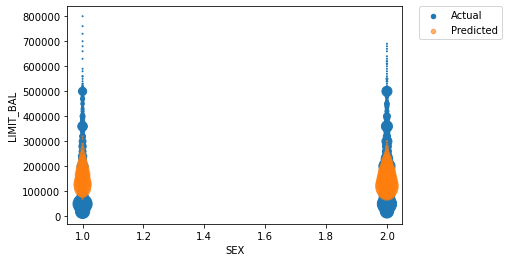

LIMIT_BAL by EDUCATION


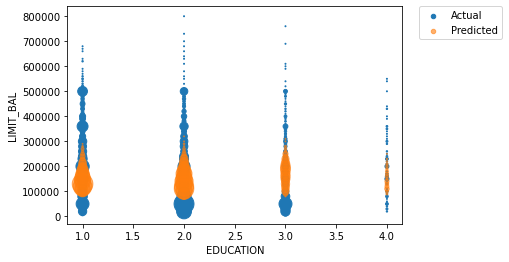

LIMIT_BAL by MARRIAGE


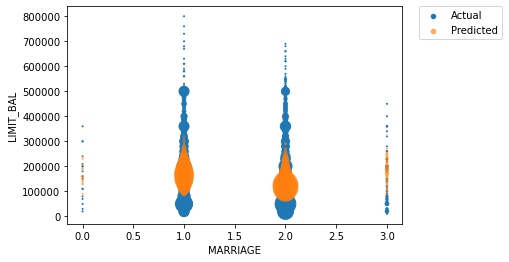

LIMIT_BAL by AGE


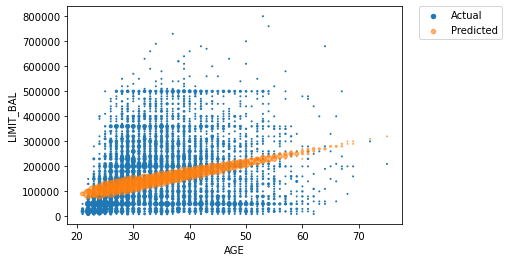

LIMIT_BAL by PAY_0


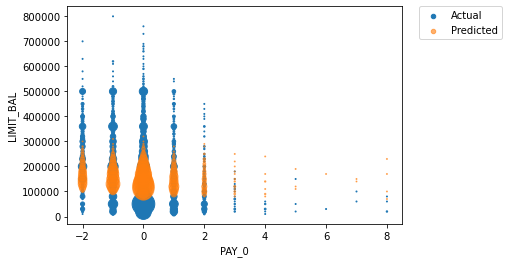

In [101]:
X_test=acc['X_test']
X_test_reset=X_test.reset_index()
y_test=acc['y_test']
#ROUND to make bubble sizes look correct
preds=acc['preds'].round(-4)
for column in X_test.columns:
    print('%s by %s' %(dep_var,column))
    df=pd.concat([X_test[column],y_test],axis=1)
    #print(df.describe())
    #print(df.head())
    #print(df.tail())
    df=df.groupby(by=[column,dep_var]).size().reset_index(name='count')
    pred_df=pd.concat([X_test_reset[column],pd.DataFrame(preds,columns=[dep_var])],axis=1)
    #print(pred_df.describe())
    #print(pred_df.head())
    #print(pred_df.tail())
    pred_df=pred_df.groupby(by=[column,dep_var]).size().reset_index(name='count')
    act_s=plt.scatter(x=column,y=dep_var,s='count',marker='o',data=df)
    pred_s=plt.scatter(x=column,y=dep_var,s='count',marker='o',data=pred_df,alpha=0.6)
    plt.ticklabel_format(style='plain',axis='y')
    plt.ylabel(dep_var)
    plt.xlabel(column)
    location = 0 # For the best location
    #legend_drawn_flag = True
    #legend = plt.legend(frameon=True)
    lgnd=plt.legend((act_s,pred_s),('Actual', 'Predicted'),bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    for handle in lgnd.legendHandles:
        handle.set_sizes([20.0])
    plt.show()

# Try Classification

In [121]:
#pick the independent/dependent variables and set up appropriate dataframes
ind_vars=['SEX','EDUCATION','MARRIAGE','AGE','PAY_0']
X=data[ind_vars]
#print(X.head())
dep_var='LIMIT_BAL_BIN'
y=data[dep_var]
#print(y.head())

#decide if were running regression or classification (r or c)
model_type='c'

#variable to hold the proportion of data to test on
test_prop=0.3

#arrays to hold the possible folds to use during cross validation as well as the possible depths/n_lines to use during modeling
folds = [5]
depths=[3]

#check to see if any variables are constant.  Remove if they are.
for var in ind_vars:
        if data[var].max()==data[var].min():
            ind_vars.remove(var)

            
#####loop through the choices#####
#Sometimes it seems helpful to look for patterns in slices of the original dataset
#This dataframe will hold the accuracy for of the best model for each slice considered
df_acc_graph=pd.DataFrame(columns=['DEFAULT','max accuracy'])

#This loop allows us to run the same analysis on several slices of the data
#in this particlar problem were interested in predicting based on non-defaulters' behavior, so we'll use default=0 as our only slice
for r in range(0,1):
    data = pd.read_csv('credit_cleaned_transformed.csv')
    data=data[data['DEFAULT']==r]
    X=data[ind_vars]
    #print(X.head())
    y=data[dep_var]
    #print(y.head())
    #prettify results
    display(HTML('<h3>Default = '+str(r)+'</h3>'))
    display(HTML('<hr>'))

#This dataframe holds results from each individual model ran (not necesarily the best model)
    classify=pd.DataFrame(columns=['model','ind_vars','dep_var','folds','depth','accuracy'])
    
#this dataframe holds feature importance type data
    df_imp=pd.DataFrame()
    
#This loop allows the number of cross validation folds (f) as well as the depth/n_jobs (d) of the model to be adjusted 
    for f,d in product(folds,depths):
        try:
            model=get_model(X,y,model_type,f)
            print('get_model finished...')
            print('Result:'+model)
            print('...onto get_acc')
            acc=get_acc(X,y,ind_vars,dep_var,model,test_prop,f,d)
            add_row=acc['df']
            if df_imp.size!=0:
                df_imp=df_imp.append(pd.DataFrame.from_dict(acc['imp']))
            else:
                df_imp=pd.DataFrame.from_dict(acc['imp'])
            classify=classify.append(add_row)
        except Exception as E:
            print(E)
            continue
    cols=classify.columns.tolist()
#prettify outputs
    display(HTML('<h4>Accuracy Table<h4>'))
    display(HTML(classify[cols].sort_values(by='accuracy', ascending=False).to_html(index=False)))
    display(HTML('<h4>Feature Importance<h4>'))
    display(HTML(df_imp.mean().to_frame().to_html(header=False)))
    df_acc_graph.loc[r-1]=[r,classify['accuracy'].max()]
#plot accuracy results for each slice of data
#Not needed right now because we only have 1 slice we're considering
#ax=df_acc_graph.plot.bar(x='DEFAULT',y='max accuracy',rot=0,ylim=(0,1),legend=False)
#ax.set_xlabel('DEFAULT')
#ax.set_ylabel('accuracy')
#ax.yaxis.set_major_formatter(mtick.PercentFormatter())

running classification cross val for dtc with 5 folds
running classification cross val for rfc with 5 folds
running classification cross val for gbc with 5 folds
get_model finished...
Result:rfc
...onto get_acc


model,ind_vars,dep_var,folds,depth,accuracy
rfc,"[SEX, EDUCATION, MARRIAGE, AGE, PAY_0]",LIMIT_BAL_BIN,5,3,0.427389


SEX,0.026102
EDUCATION,0.204995
MARRIAGE,0.012501
AGE,0.511463
PAY_0,0.244939


LIMIT_BAL_BIN by SEX


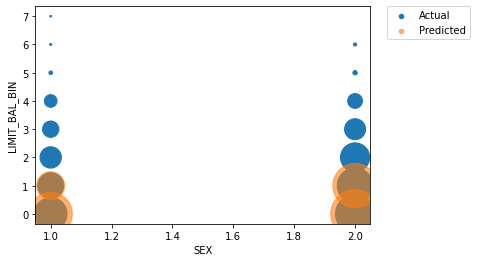

LIMIT_BAL_BIN by EDUCATION


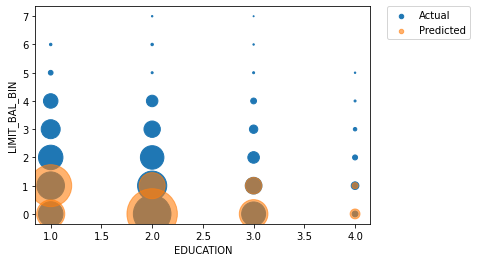

LIMIT_BAL_BIN by MARRIAGE


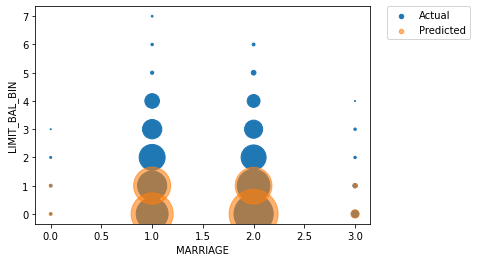

LIMIT_BAL_BIN by AGE


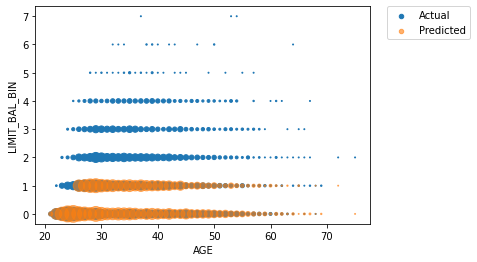

LIMIT_BAL_BIN by PAY_0


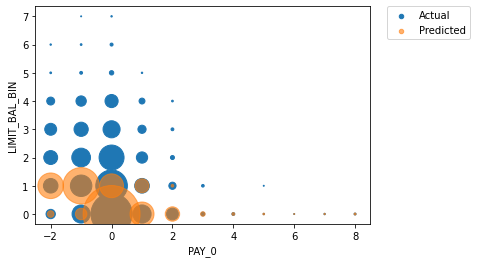

In [122]:
X_test=acc['X_test']
X_test_reset=X_test.reset_index()
y_test=acc['y_test']
preds=acc['preds']
for column in X_test.columns:
    print('%s by %s' %(dep_var,column))
    df=pd.concat([X_test[column],y_test],axis=1)
    #print(df.describe())
    #print(df.head())
    #print(df.tail())
    df=df.groupby(by=[column,dep_var]).size().reset_index(name='count')
    pred_df=pd.concat([X_test_reset[column],pd.DataFrame(preds,columns=[dep_var])],axis=1)
    #print(pred_df.describe())
    #print(pred_df.head())
    #print(pred_df.tail())
    pred_df=pred_df.groupby(by=[column,dep_var]).size().reset_index(name='count')
    act_s=plt.scatter(x=column,y=dep_var,s='count',marker='o',data=df)
    pred_s=plt.scatter(x=column,y=dep_var,s='count',marker='o',data=pred_df,alpha=0.6)
    plt.ticklabel_format(style='plain',axis='y')
    plt.ylabel(dep_var)
    plt.xlabel(column)
    lgnd=plt.legend((act_s,pred_s),('Actual', 'Predicted'),bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    for handle in lgnd.legendHandles:
        handle.set_sizes([20.0])
    plt.show()

# Try to classify just default status

In [123]:
#pick the independent/dependent variables and set up appropriate dataframes
ind_vars=['PAY_0','SEX','EDUCATION','MARRIAGE','AGE']
dep_var='DEFAULT'

#decide if were running regression or classification (r or c)
model_type='c'

#variable to hold the proportion of data to test on
test_prop=0.3

#arrays to hold the possible folds to use during cross validation as well as the possible depths/n_lines to use during modeling
folds = [5]
depths=[3]

#check to see if any variables are constant.  Remove if they are.
for var in ind_vars:
        if data[var].max()==data[var].min():
            ind_vars.remove(var)


#This dataframe holds results from each individual model ran (not necesarily the best model)
classify=pd.DataFrame(columns=['model','ind_vars','dep_var','folds','depth','accuracy'])
    
#this dataframe holds feature importance type data
df_imp=pd.DataFrame()
data = pd.read_csv('credit_cleaned_transformed.csv')
X=data[ind_vars]
#print(X.head())
y=data[dep_var]
#print(y.head())

#This loop allows the number of cross validation folds (f) as well as the depth/n_jobs (d) of the model to be adjusted 
for f,d in product(folds,depths):
    try:
        model=get_model(X,y,model_type,f)
        print('get_model finished...')
        print('Result:'+model)
        print('...onto get_acc')
        acc=get_acc(X,y,ind_vars,dep_var,model,test_prop,f,d)
        add_row=acc['df']
        if df_imp.size!=0:
            df_imp=df_imp.append(pd.DataFrame.from_dict(acc['imp']))
        else:
            df_imp=pd.DataFrame.from_dict(acc['imp'])
        classify=classify.append(add_row)
    except Exception as E:
        print(E)
        continue
cols=classify.columns.tolist()
#prettify outputs
display(HTML('<h4>Accuracy Table<h4>'))
display(HTML(classify[cols].sort_values(by='accuracy', ascending=False).to_html(index=False)))
display(HTML('<h4>Feature Importance<h4>'))
display(HTML(df_imp.mean().to_frame().to_html(header=False)))
df_acc_graph.loc[r-1]=[r,classify['accuracy'].max()]


running classification cross val for dtc with 5 folds
running classification cross val for rfc with 5 folds
running classification cross val for gbc with 5 folds
get_model finished...
Result:dtc
...onto get_acc


model,ind_vars,dep_var,folds,depth,accuracy
dtc,"[PAY_0, SEX, EDUCATION, MARRIAGE, AGE]",DEFAULT,5,3,0.824333


PAY_0,0.981793
SEX,0.003442
EDUCATION,0.006664
MARRIAGE,0.003340
AGE,0.004762


DEFAULT by PAY_0


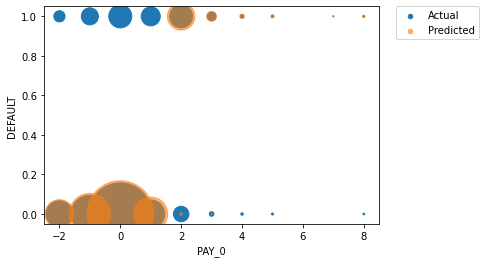

DEFAULT by SEX


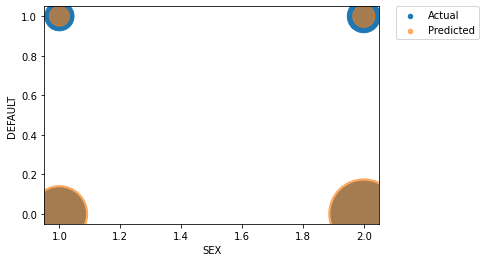

DEFAULT by EDUCATION


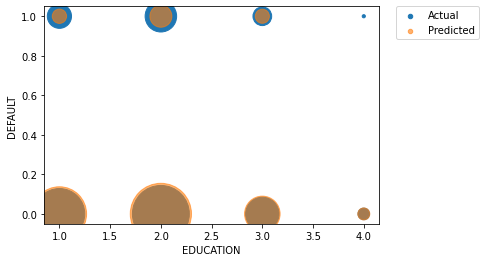

DEFAULT by MARRIAGE


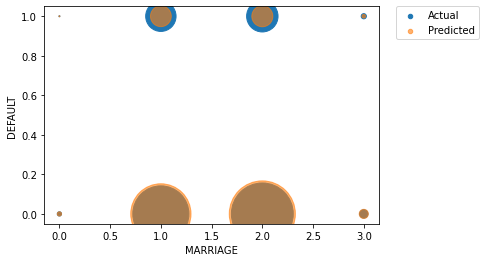

DEFAULT by AGE


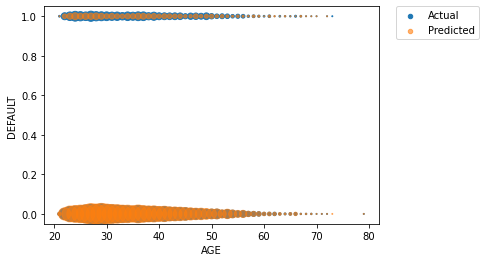

In [128]:
plt.clf
X_test=acc['X_test']
X_test_reset=X_test.reset_index()
y_test=acc['y_test']
preds=acc['preds']
for column in X_test.columns:
    print('%s by %s' %(dep_var,column))
    df=pd.concat([X_test[column],y_test],axis=1)
    #print(df.describe())
    #print(df.head())
    #print(df.tail())
    df=df.groupby(by=[column,dep_var]).size().reset_index(name='count')
    pred_df=pd.concat([X_test_reset[column],pd.DataFrame(preds,columns=[dep_var])],axis=1)
    #print(pred_df.describe())
    #print(pred_df.head())
    #print(pred_df.tail())
    pred_df=pred_df.groupby(by=[column,dep_var]).size().reset_index(name='count')
    act_s=plt.scatter(x=column,y=dep_var,s='count',marker='o',data=df)
    pred_s=plt.scatter(x=column,y=dep_var,s='count',marker='o',data=pred_df,alpha=0.6)
    plt.ticklabel_format(style='plain',axis='y')
    plt.ylabel(dep_var)
    plt.xlabel(column)
    lgnd=plt.legend((act_s,pred_s),('Actual', 'Predicted'),bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    for handle in lgnd.legendHandles:
        handle.set_sizes([20.0])
    plt.show()